# Predict substitution and deletion variant effects with PoET

This tutorial demonstrates how to use PoET to score substitution and deletion variants of a sequence using aliphatic amidase (`AMIE_PSEAE`) as an example. We'll also compare substitution variant scores from PoET, ESM1b, and a site-independent model (PSSM) with activities assayed in a deep mutational scanning study by {AUTHORS}.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy.stats import pearsonr,spearmanr,kendalltau
import scipy.special
import json
import time

In [3]:
import openprotein
import openprotein.fasta as fasta

In [4]:
name = 'AMIE_PSEAE'
wt = b'MRHGDISSSNDTVGVAVVNYKMPRLHTAAEVLDNARKIAEMIVGMKQGLPGMDLVVFPEYSLQGIMYDPAEMMETAVAIPGEETEIFSRACRKANVWGVFSLTGERHEEHPRKAPYNTLVLIDNNGEIVQKYRKIIPWCPIEGWYPGGQTYVSEGPKGMKISLIICDDGNYPEIWRDCAMKGAELIVRCQGYMYPAKDQQVMMAKAMAWANNCYVAVANAAGFDGVYSYFGHSAIIGFDGRTLGECGEEEMGIQYAQLSLSQIRDARANDQSQNHLFKILHRGYSGLQASGDGDRGLAECPFEFYRTWVTDAEKARENVERLTRSTTGVAQCPVGRLPYEGLEKEA'

print('>' + name)
for i in range(0, len(wt), 80):
    print(wt[i:i+80].decode())

>AMIE_PSEAE
MRHGDISSSNDTVGVAVVNYKMPRLHTAAEVLDNARKIAEMIVGMKQGLPGMDLVVFPEYSLQGIMYDPAEMMETAVAIP
GEETEIFSRACRKANVWGVFSLTGERHEEHPRKAPYNTLVLIDNNGEIVQKYRKIIPWCPIEGWYPGGQTYVSEGPKGMK
ISLIICDDGNYPEIWRDCAMKGAELIVRCQGYMYPAKDQQVMMAKAMAWANNCYVAVANAAGFDGVYSYFGHSAIIGFDG
RTLGECGEEEMGIQYAQLSLSQIRDARANDQSQNHLFKILHRGYSGLQASGDGDRGLAECPFEFYRTWVTDAEKARENVE
RLTRSTTGVAQCPVGRLPYEGLEKEA


## Connect to the OpenProtein.AI API

In [5]:
with open('secrets.config', 'r') as f:
    config = json.load(f)

session = openprotein.connect(config['username'], config['password'])

## Create the MSA and define an ensemble prompt

To run PoET, we use the OpenProtein API to construct an MSA from homologues of the wildtype sequence using homology search and then define an ensemble prompt containing 10 prompts sampled with default parameters. Query sequences will then be scored conditioned on the fitness landscape represented by the sequences in the prompt.

OpenProtein uses an asynchronous API, where potentially long running functions return a job ID that can be used to query for completed results. The `wait_until_done` function can be used to poll for completion.

In [6]:
# search for homologs to automatically create an MSA for the seed sequence
msa = session.poet.create_msa(wt)
print(msa)
msa.wait_until_done(verbose=True)

# create the prompt, set the seed for reproducibility
prompt = msa.sample_prompt(num_ensemble_prompts=10, random_seed=1)
print(prompt)
prompt.wait_until_done(verbose=True)

model_config={'protected_namespaces': ()} status=<JobStatus.SUCCESS: 'SUCCESS'> job_id='50fadb5e-d784-4c04-8fa1-294ace009075' job_type='/align/align' created_date=datetime.datetime(2023, 9, 16, 17, 27, 32, 34325) start_date=None end_date=datetime.datetime(2023, 9, 16, 17, 27, 32, 77691) prerequisite_job_id=None progress_message=None progress_counter=None num_records=None msa_id='50fadb5e-d784-4c04-8fa1-294ace009075'


Waiting: 100%|██████████| 100/100 [00:00<00:00, 291.03it/s, status=SUCCESS]


model_config={'protected_namespaces': ()} status=<JobStatus.PENDING: 'PENDING'> job_id='0d59efdb-dabc-4402-825b-73025edd0522' job_type='/align/prompt' created_date=datetime.datetime(2023, 9, 16, 17, 27, 32, 769154) start_date=None end_date=None prerequisite_job_id=None progress_message=None progress_counter=None num_records=None msa_id=None prompt_id='0d59efdb-dabc-4402-825b-73025edd0522'


Waiting: 100%|██████████| 100/100 [00:27<00:00,  3.70it/s, status=SUCCESS]


True

## Run all single substitution predictions for the parent sequence

All single substitutions can be scored using the `session.poet.single_site` function.

In [7]:
future_ssp = session.poet.single_site(prompt, wt)
print(future_ssp.job)
future_ssp.wait_until_done(verbose=True)

model_config={'protected_namespaces': ()} status=<JobStatus.PENDING: 'PENDING'> job_id='780766ef-d263-42c3-9456-8f221c490c47' job_type='/poet/single_site' created_date=datetime.datetime(2023, 9, 16, 17, 28, 3, 449996) start_date=None end_date=None prerequisite_job_id=None progress_message=None progress_counter=None num_records=None parent_id=None s3prefix=None page_size=None page_offset=None num_rows=None result=None n_completed=None


Waiting: 100%|██████████| 100/100 [09:41<00:00,  5.81s/it, status=SUCCESS]


True

In [8]:
# retrieve the results for the SSP job
results = future_ssp.get()

In [9]:
# parse results into matrix of variants at each site
result_dict = {}
for r in results:
    result_dict[r.sequence] = np.array(r.score)

baseline = result_dict[b'input']
amino_acids = b'ARNDCQEGHILKMFPSTWYV'

scores_ensemble = np.zeros((len(wt), 20, len(baseline))) + baseline
for i in range(scores_ensemble.shape[0]):
    for j in range(len(amino_acids)):
        pos = i + 1
        fr = wt[i:i+1]
        to = amino_acids[j:j+1]
        if fr != to:
            code = fr + str(pos).encode() + to
            val = result_dict[code]
            scores_ensemble[i, j] = val
scores_ensemble.shape

(346, 20, 10)

### Plot the single site predictions

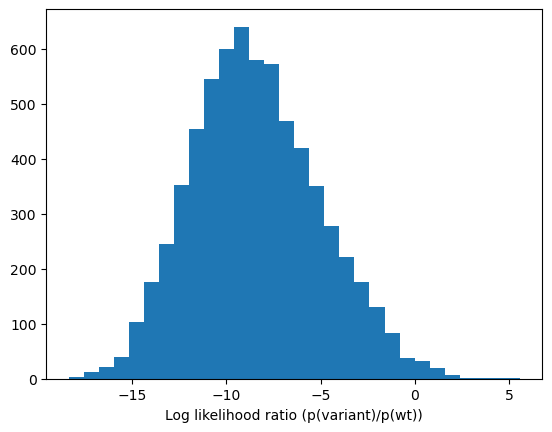

In [10]:
scores = np.stack(list(result_dict.values()), axis=0) - baseline
scores = scores.mean(axis=-1)
_ = plt.hist(scores.ravel(), bins=30)
_ = plt.xlabel('Log likelihood ratio (p(variant)/p(wt))')

Text(0.5, 0, 'Position')

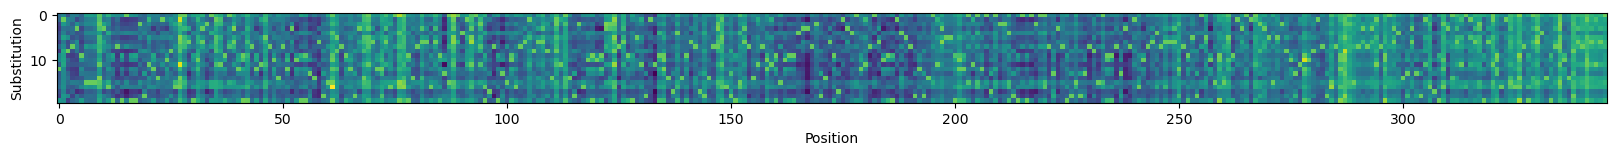

In [11]:
scores = np.mean(scores_ensemble - baseline, axis=-1)
_, ax = plt.subplots(figsize=(20, 4))
ax.imshow(scores.T)
plt.ylabel('Substitution')
plt.xlabel('Position')

### Plot scores from an individual prompts in the ensemble

Because we used a prompt ensemble, we get scores for each prompt in the ensemble. They can be combined into a single score via averaging, but can also be examined individually.

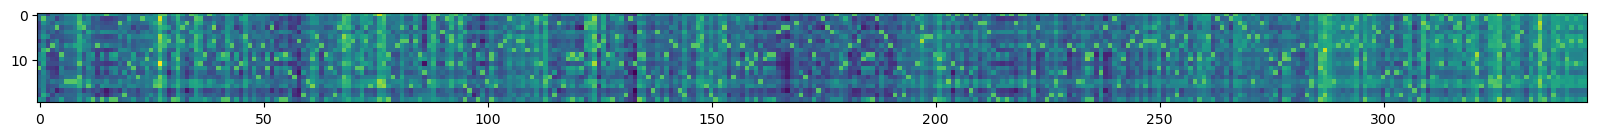

In [12]:
_, ax = plt.subplots(figsize=(20, 4))

heatmap = scores_ensemble[..., 0] - baseline[..., 0]
ax.imshow(heatmap.T)

### Rank PoET variant predictions

In [13]:
variants, scores = zip(*result_dict.items())
variants = np.array(variants)
scores = np.array(scores)
variants.shape, scores.shape

((6575,), (6575, 10))

In [14]:
# rank the variants
order = np.argsort(-scores.mean(axis=1))
for i in order[:10]:
    print(variants[i].decode(), scores[i].mean(axis=-1), (scores[i]-baseline).mean(axis=-1))

L62T -140.06779766082764 5.570239067077635
A28K -140.98878440856933 4.649252319335934
I279L -141.4669720649719 4.1710646629333485
A28R -141.7436710357666 3.8943656921386776
Q288H -142.2893359184265 3.3487008094787543
V77A -142.6376898765564 3.00034685134888
K93E -143.45875930786133 2.1792774200439426
T327V -143.4867042541504 2.1513324737548816
S285T -143.63027153015136 2.0077651977539035
N125K -143.64069890975952 1.9973378181457506


## Compare the PoET substitution scores with measurements from deep mutational scanning

Deep mutational scanning of `AMIE_PSEAE` has been performed by AUTHORS. In this study, they measured activites of most single substitution variants of the wildtype protein against three substrates. Let's load this data and see how well PoET predicted the effects of these variants compared with a few baselines.

As baselines, we'll consider
* a position-specific scoring matrix (**PSSM**, and additive model) fit on the MSA found above
* variant effect predictions from the per-position amino acid probabilities given by **ESM1b**

### Load the DMS data

In [15]:
path = 'data/AMIE_PSEAE_Whitehead.csv'
table = pd.read_csv(path, index_col=0)
table.head()

,mutant,acetamide_normalized_fitness,isobutyramide_normalized_fitness,propionamide_normalized_fitness,mutation_effect_prediction_vae_ensemble,mutation_effect_prediction_vae_1,mutation_effect_prediction_vae_2,mutation_effect_prediction_vae_3,mutation_effect_prediction_vae_4,mutation_effect_prediction_vae_5,mutation_effect_prediction_pairwise,mutation_effect_prediction_independent
0,M1W,NaN,-0.5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M1Y,NaN,-0.5253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M1P,-2.1514,-0.5154,-1.1457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M1M,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M1I,-0.1227,-0.3640,-0.1212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
cols = ['acetamide_normalized_fitness', 'isobutyramide_normalized_fitness', 'propionamide_normalized_fitness']
variants = table['mutant']

### Match against the DMS variants and compare PoET log probabilities with activity measurements

PoET log probabilities accurately predict the activity of AMIE variants for all three substrates.

In [17]:
baseline = result_dict[b'input']
variants = table['mutant'].values
logp = np.array([result_dict.get(code.encode(), baseline) for code in variants])
logp.shape

(6819, 10)

acetamide_normalized_fitness 0.4915317398404091 0.668598164527978
isobutyramide_normalized_fitness 0.5794655118538244 0.6288443026870727
propionamide_normalized_fitness 0.6025013807666131 0.6578263641561621


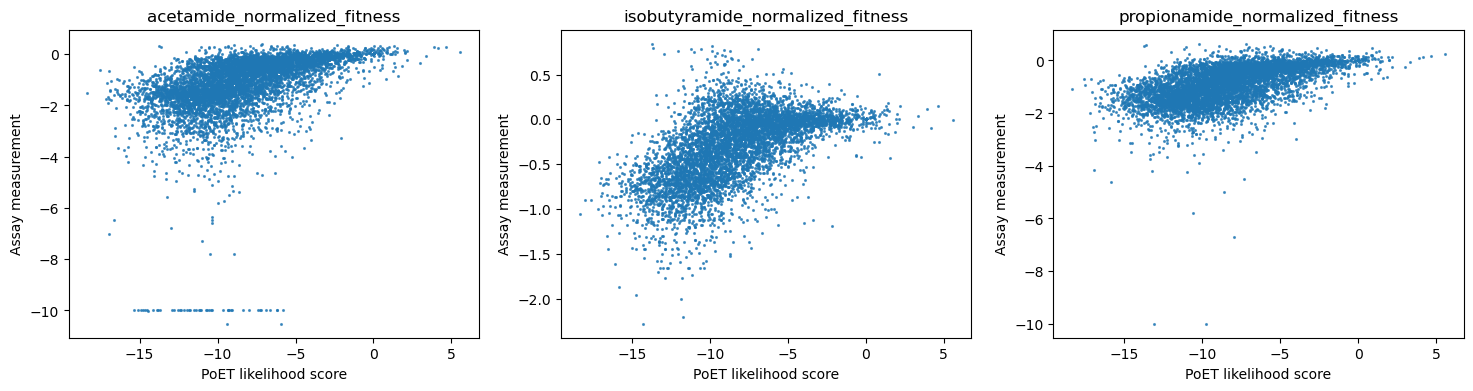

In [18]:
scores = np.mean(logp, axis=-1) - baseline.mean()
sigma = np.std(logp - baseline, axis=-1)

_, axs = plt.subplots(1, len(cols), figsize=(6*len(cols), 4))
for i in range(len(cols)):
    c = cols[i]
    y = table[c].values
    axs[i].scatter(scores, y, s=1.5, alpha=0.7)
    axs[i].set_title(c)
    axs[i].set_xlabel('PoET likelihood score')
    axs[i].set_ylabel('Assay measurement')

    mask = np.isnan(y)
    r = pearsonr(scores[~mask], y[~mask])[0]
    rho = spearmanr(scores[~mask], y[~mask])[0]
    print(c, r, rho)

#### Compare predictiveness of single prompts with the ensemble

In [19]:
scores = np.mean(logp, axis=-1)
sigma = np.std(logp - baseline, axis=-1)

rows = []
for i in range(logp.shape[-1]):
    pred = logp[..., i]
    row = [f'Prompt {i+1}']
    for j in range(len(cols)):
        c = cols[j]
        y = table[c].values
        mask = np.isnan(y)
        rho = spearmanr(pred[~mask], y[~mask])[0]
        row.append(rho)
    rows.append(row)

arr = pd.DataFrame(rows).iloc[:, 1:].values
means = arr.mean(axis=0)
rows.append(['Average'] + means.tolist())

pred = scores
row = [f'Ensemble']
for j in range(len(cols)):
    c = cols[j]
    y = table[c].values
    mask = np.isnan(y)
    rho = spearmanr(pred[~mask], y[~mask])[0]
    row.append(rho)
rows.append(row)

ensemble_comparison_table = pd.DataFrame(rows, columns=['Prompt'] + cols)
ensemble_comparison_table

,Prompt,acetamide_normalized_fitness,isobutyramide_normalized_fitness,propionamide_normalized_fitness
0,Prompt 1,0.657038,0.606791,0.646580
1,Prompt 2,0.670391,0.618418,0.660468
2,Prompt 3,0.608870,0.566996,0.588741
3,Prompt 4,0.647733,0.618528,0.640674
4,Prompt 5,0.655066,0.617874,0.647239
5,Prompt 6,0.678674,0.532794,0.644024
6,Prompt 7,0.648721,0.630591,0.644455
7,Prompt 8,0.627783,0.617337,0.621517
8,Prompt 9,0.620926,0.611542,0.616554
9,Prompt 10,0.635976,0.624271,0.634767


### Compare the PoET scores with a PSSM and ESM1b

PoET is significantly more predictive, especially for acetamide and propionamide.

In [20]:
# retrieve the MSA and fit the PSSM
msa_sequences = []
for name, sequence in msa.get():
    msa_sequences.append(sequence)
msa_sequences = np.array([[c for c in msa_sequences[i]] for i in range(len(msa_sequences))])
msa_sequences.shape

(1244, 346)

#### Calculate the PSSM scores

In [21]:
# count the amino acids at each site and calculate site frequencies with a small pseudocount
from collections import Counter
pseudocount = 1

pssm = []
for i in range(msa_sequences.shape[1]):
    counts = Counter(msa_sequences[:, i])
    freqs = {}
    total = sum(counts.get(a, 0) + pseudocount for a in amino_acids.decode())
    for a in amino_acids.decode():
        c = counts.get(a, 0) + pseudocount
        freqs[a] = np.log(c) - np.log(total)
    pssm.append(freqs)

In [22]:
# score the variants in the DMS dataset using the PSSM
scores_pssm = np.zeros(len(table))

# first, score the WT
logp_pssm_wt = 0
for j, aa in enumerate(wt.decode()):
    logp_pssm_wt += pssm[j][aa]

for i,mut in enumerate(table['mutant'].values):
    # parse the mutant sequence
    wt_aa, site, var_aa = mut[:1], int(mut[1:-1])-1, mut[-1:]
    assert wt_aa == wt[site:site+1].decode(), f'{wt_aa}, {wt[site]}, {site}'
    s = wt[:site].decode() + var_aa + wt[site+1:].decode()
    logp = 0
    for j, aa in enumerate(s):
        logp += pssm[j][aa]
    scores_pssm[i] = logp
scores_pssm = scores_pssm - logp_pssm_wt
scores_pssm.shape

(6819,)

acetamide_normalized_fitness 0.36415933957093305 0.49663192553097374
isobutyramide_normalized_fitness 0.45856822253448065 0.5050335369506086
propionamide_normalized_fitness 0.4545880151016231 0.4934338235422932


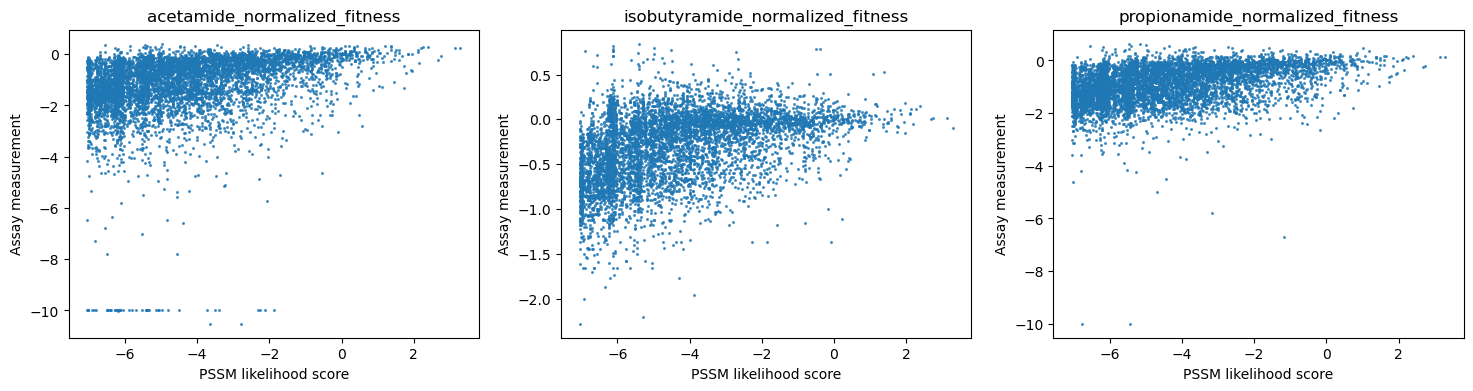

In [23]:
_, axs = plt.subplots(1, len(cols), figsize=(6*len(cols), 4))
for i in range(len(cols)):
    c = cols[i]
    y = table[c].values
    axs[i].scatter(scores_pssm, y, s=1.5, alpha=0.7)
    axs[i].set_title(c)
    axs[i].set_xlabel('PSSM likelihood score')
    axs[i].set_ylabel('Assay measurement')

    mask = np.isnan(y)
    r = pearsonr(scores_pssm[~mask], y[~mask])[0]
    rho = spearmanr(scores_pssm[~mask], y[~mask])[0]
    print(c, r, rho)

#### Calculate the ESM1b scores using the API

In [24]:
esm1b = session.embedding.get_model('esm1b_t33_650M_UR50S')

# to make the ESM1b scores, we get the probability of the amino acids at each site if the site is masked
# ESM1b will return logits flanked by start and stop token positions
queries = []
for i in range(len(wt)):
    q = wt[:i] + b'X' + wt[i+1:]
    queries.append(q)
future_logits_esm1b = esm1b.logits(queries)

print(future_logits_esm1b.job)
future_logits_esm1b.wait_until_done(verbose=True)

model_config={'protected_namespaces': ()} status=<JobStatus.PENDING: 'PENDING'> job_id='0c41f120-e803-413d-83ba-42de97905d32' job_type='/embeddings/logits' created_date=datetime.datetime(2023, 9, 16, 17, 38, 16, 448730, tzinfo=datetime.timezone.utc) start_date=None end_date=None prerequisite_job_id=None progress_message=None progress_counter=0 num_records=346


Waiting: 100%|██████████| 100/100 [00:05<00:00, 17.18it/s, status=SUCCESS]


True

In [25]:
results_esm1b = future_logits_esm1b.get()
# parse the site potentials out from the results for each masked site
logits_esm1b = [None]*len(wt)
for sequence, array in results_esm1b:
    # discard the leading <cls> token and the trailing <eos> token
    array = array[1:-1]
    # find the masked position to get the logits there
    i = sequence.index(b'X')
    logits_esm1b[i] = array[i]
logits_esm1b = np.stack(logits_esm1b, axis=0)

# parse the tokens
tokens = esm1b.metadata.output_tokens[:logits_esm1b.shape[1]]
esm1b_scoring_matrix = []
for i in range(len(wt)):
    s = scipy.special.log_softmax(logits_esm1b[i])
    site_scores = {}
    for j,t in enumerate(tokens):
        site_scores[t] = s[j]
    esm1b_scoring_matrix.append(site_scores)

logits_esm1b.shape

(346, 33)

In [26]:
# score the variants in the DMS dataset using the PSSM
scores_esm1b = np.zeros(len(table))

# first, score the WT
logp_esm1b_wt = 0
for j, aa in enumerate(wt.decode()):
    logp_esm1b_wt += esm1b_scoring_matrix[j][aa]

for i,mut in enumerate(table['mutant'].values):
    # parse the mutant sequence
    wt_aa, site, var_aa = mut[:1], int(mut[1:-1])-1, mut[-1:]
    assert wt_aa == wt[site:site+1].decode(), f'{wt_aa}, {wt[site]}, {site}'
    s = wt[:site].decode() + var_aa + wt[site+1:].decode()
    logp = 0
    for j, aa in enumerate(s):
        logp += esm1b_scoring_matrix[j][aa]
    scores_esm1b[i] = logp
scores_esm1b = scores_esm1b - logp_esm1b_wt
scores_esm1b.shape

(6819,)

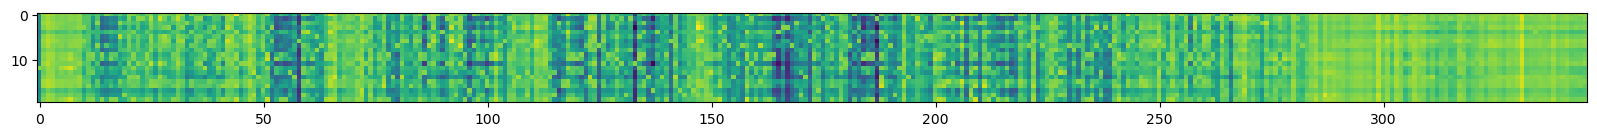

In [27]:
score_map_esm1b = np.zeros((len(wt), 20))
for i in range(len(wt)):
    for j in range(20):
        aa = amino_acids[j:j+1].decode()
        score_map_esm1b[i, j] = esm1b_scoring_matrix[i][aa] - esm1b_scoring_matrix[i][wt[i:i+1].decode()]

_, ax = plt.subplots(figsize=(20, 4))
ax.imshow(score_map_esm1b.T)

acetamide_normalized_fitness 0.3020148994863302 0.4431017510346242
isobutyramide_normalized_fitness 0.5846380794728829 0.5928629494149119
propionamide_normalized_fitness 0.4091775908979456 0.46330056813108


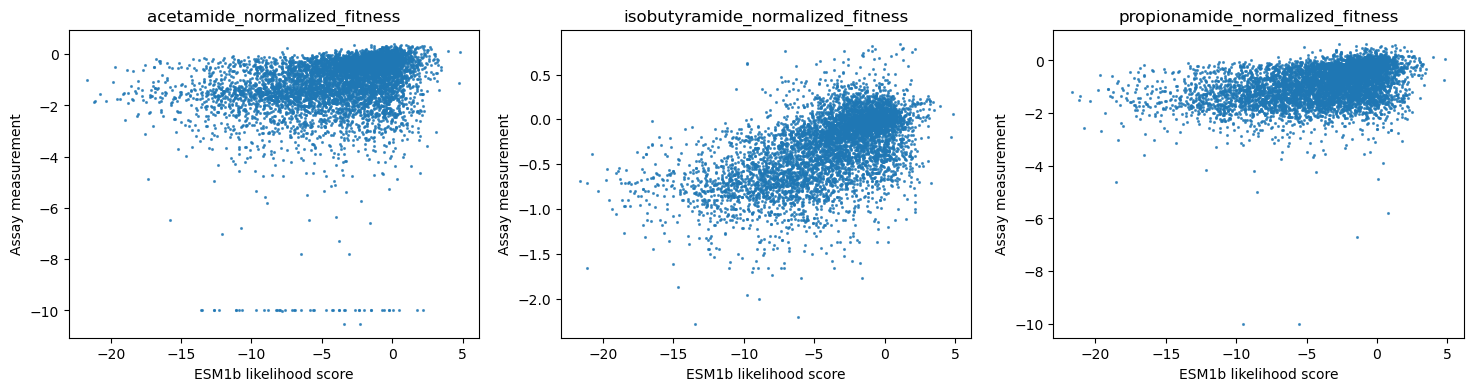

In [28]:
_, axs = plt.subplots(1, len(cols), figsize=(6*len(cols), 4))
for i in range(len(cols)):
    c = cols[i]
    y = table[c].values
    axs[i].scatter(scores_esm1b, y, s=1.5, alpha=0.7)
    axs[i].set_title(c)
    axs[i].set_xlabel('ESM1b likelihood score')
    axs[i].set_ylabel('Assay measurement')

    mask = np.isnan(y)
    r = pearsonr(scores_esm1b[~mask], y[~mask])[0]
    rho = spearmanr(scores_esm1b[~mask], y[~mask])[0]
    print(c, r, rho)

### Compare PoET scores with PSSM and ESM1b scores

Calculate the rank correlation coefficients. Scores from PoET correlate significantly better with measured activity, especially for acetamide and propionamide substrates.

In [29]:
from IPython.display import display

scores_vae = table['mutation_effect_prediction_vae_ensemble'].values
vae_mask = np.isnan(scores_vae)

score_names = ['PSSM', 'ESM1b', 'PoET']
score_arrays = [scores_pssm, scores_esm1b, scores]

rows = []
for i in range(len(cols)):
    c = cols[i]
    y = table[c].values
    mask = np.isnan(y)
    rhos = []
    for j in range(len(score_names)):
        rho = spearmanr(score_arrays[j][~mask], y[~mask])[0]
        rhos.append(rho)
    axs[i].set_title(c)

    row = [c] + rhos
    rows.append(row)

result_table = pd.DataFrame(rows, columns=['Property'] + score_names)
display(result_table)

,Property,PSSM,ESM1b,PoET
0,acetamide_normalized_fitness,0.496632,0.443102,0.668598
1,isobutyramide_normalized_fitness,0.505034,0.592863,0.628844
2,propionamide_normalized_fitness,0.493434,0.463301,0.657826


## Analyze deletion variants of AMIE_PSEAE

### Single deletion screen

Predict the deletion tolerance for each site in `AMIE_PSEAE` using the `score` function of PoET to evaluate the log-likelihoods of specified sequences.

In [30]:
queries = [wt]
for i in range(len(wt)):
    q = wt[:i] + wt[i+1:]
    queries.append(q)
len(queries)

347

In [31]:
future_score = session.poet.score(prompt, queries)
print(future_score.job)
future_score.wait_until_done(verbose=True)

model_config={'protected_namespaces': ()} status=<JobStatus.PENDING: 'PENDING'> job_id='8d9ae707-ac82-4dd0-afab-75a1f973255e' job_type='/poet' created_date=datetime.datetime(2023, 9, 16, 17, 38, 39, 225981) start_date=None end_date=None prerequisite_job_id=None progress_message=None progress_counter=None num_records=None parent_id=None s3prefix=None page_size=None page_offset=None num_rows=None result=None n_completed=None


Waiting:  25%|██▌       | 25/100 [00:54<02:42,  2.17s/it, status=RUNNING]

In [ ]:
results_del_scan = future_score.get()

In [ ]:
scores_del_ensemble = np.stack([r.score for r in results_del_scan], axis=0)
scores_del_ensemble.shape

(347, 10)

Text(0.5, 1.0, 'Deletion Tolerance Scan')

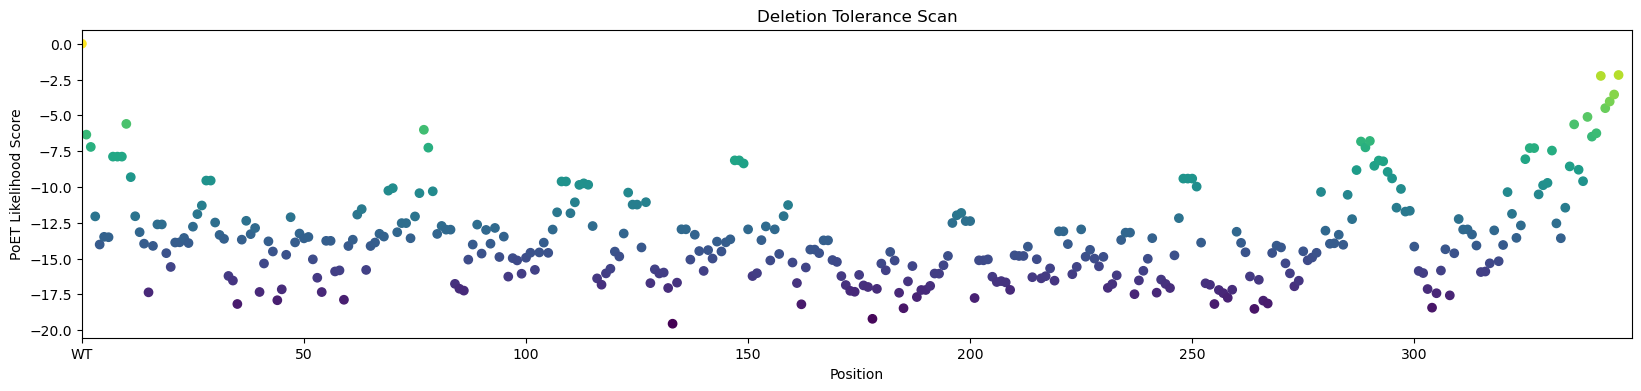

In [ ]:
scores_del = np.mean(scores_del_ensemble - baseline, axis=-1)

_, ax = plt.subplots(figsize=(20, 4))
ax.scatter(np.arange(0, len(wt)+1), scores_del)
ax.set_xlim(0, len(scores_del)+2)
ax.set_xticks(np.arange(0, len(scores_del), 50), ['WT'] + [str(i) for i in np.arange(50, len(scores_del), 50)])
plt.xlabel('Position')
plt.ylabel('PoET Likelihood Score')
plt.title('Deletion Tolerance Scan')

### Deletion fragment screen

Now, let's predict the deletion tolerance for fragments (subsequence) of up to 16 amino acids by enumerating and scoring the log-likelihoods for all of them. For `AMIE_PSEAE`, there are about 5,400 possible such deletions.

In [ ]:
# enumerate WT variants with all deletions of up to size 16
# NOTE - empty string sequences are not scores by the PoET API

queries = [wt]
for i in range(len(wt)):
    for j in range(i, min(i+16, len(wt))):
        q = wt[:i] + wt[j+1:]
        queries.append(q)
len(queries)

5417

In [ ]:
# submit this in multiple chunks, because the number of query sequences is large
futures_score_del_span = []
batch_size = 1000
for i in range(0, len(queries), batch_size):
    batch = queries[i:i+batch_size]
    f = session.poet.score(prompt, batch)
    print(i, 'to', min(len(queries), i+batch_size), f.job)
    futures_score_del_span.append(f)

0 to 5000 model_config={'protected_namespaces': ()} status=<JobStatus.PENDING: 'PENDING'> job_id='e9822118-490e-425e-85cb-841f0c0f569c' job_type='/poet' created_date=datetime.datetime(2023, 9, 15, 7, 41, 21, 345997) start_date=None end_date=None prerequisite_job_id=None progress_message=None progress_counter=None num_records=None parent_id=None s3prefix=None page_size=None page_offset=None num_rows=None result=None n_completed=None
5000 to 10000 model_config={'protected_namespaces': ()} status=<JobStatus.PENDING: 'PENDING'> job_id='b443ad67-2ab9-4f83-a009-3b93e3199f10' job_type='/poet' created_date=datetime.datetime(2023, 9, 15, 7, 41, 34, 208882) start_date=None end_date=None prerequisite_job_id=None progress_message=None progress_counter=None num_records=None parent_id=None s3prefix=None page_size=None page_offset=None num_rows=None result=None n_completed=None
10000 to 15000 model_config={'protected_namespaces': ()} status=<JobStatus.PENDING: 'PENDING'> job_id='16f9d7d5-b3d6-4b9e-bb

In [ ]:
# wait for all of the score jobs to finish
for f in futures_score_del_span:
    f.wait_until_done(verbose=True)

Waiting: 100%|██████████| 100/100 [00:00<00:00, 356.15it/s, status=SUCCESS]


In [ ]:
# get all of the results for the deletion region scan
# NOTE - empty string sequences are not scores by the PoET API
results_del_scan_dict = {}
for f in futures_score_del_span:
    res = f.get()
    for r in res:
        results_del_scan_dict[r.sequence] = r.score
    print('GET', len(results_del_scan_dict))
len(results_del_scan_dict)

GET 4763
GET 9476
GET 14169
GET 18897
GET 23587
GET 28309
GET 33037
GET 37782
GET 42509
GET 47232
GET 51926
GET 56634
GET 56663


56663

In [ ]:
# match against the queries
scores_del_scan_ensemble = []
for q in queries:
    s = results_del_scan_dict.get(q, np.array([np.nan]*10)) # fill in NaN for "" fragments
    scores_del_scan_ensemble.append(s)
scores_del_scan_ensemble = np.stack(scores_del_scan_ensemble)
scores_del_scan_ensemble.shape

(60032, 10)

In [ ]:
# visualize scores for the fragment deletions
max_length = 16
scores_mat = np.zeros((len(wt), max_length)) + np.nan
for i in range(len(wt)):
    for j in range(i, min(i+max_length, len(wt))):
        q = wt[:i] + wt[j+1:]
        s = results_del_scan_dict.get(q, [np.nan]*10) # fill in NaN for "" fragments
        s = np.array(s)
        scores_mat[i, j-i] = s.mean() - baseline.mean()
scores_mat.shape

(346, 16)

Text(0.5, 1.0, 'Deletion Size Tolerance')

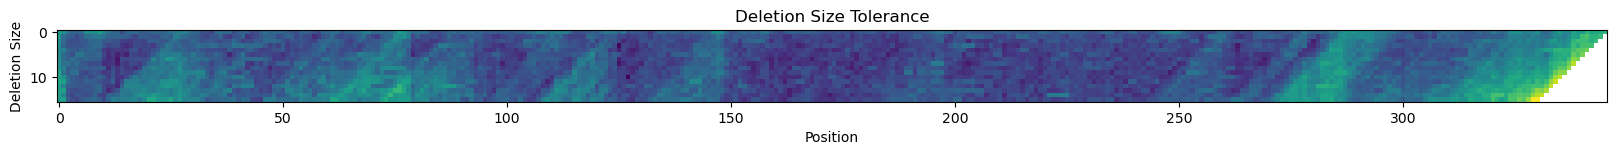

In [ ]:
_, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(scores_mat.T)
ax.set_xlabel('Position')
ax.set_ylabel('Deletion Size')
ax.set_title('Deletion Size Tolerance')
#plt.colorbar(im)

In [ ]:
# sort out the most favorable deletion starting from each position
order = np.argsort(-scores_mat.max(axis=1).ravel())
print('Score   ', 'Start,End', 'Length', 'Sequence', sep='\t')
for k in order[:10]:
    i = k
    j = np.argmax(scores_mat[i])
    #i, j = np.unravel_index(k, scores_mat.shape)
    span = (i+1, i+1+j)
    deleted_fragment = wt[i:i+j+1].decode()
    print(f'{scores_mat[i, j]:8.5f}', span, j+1, deleted_fragment, sep='\t')

Score   	Start,End	Length	Sequence
10.14641	(331, 346)	16	QCPVGRLPYEGLEKEA
10.14641	(330, 345)	16	AQCPVGRLPYEGLEKE
 4.68736	(329, 344)	16	VAQCPVGRLPYEGLEK
 1.98276	(327, 342)	16	TGVAQCPVGRLPYEGL
 0.66382	(328, 343)	16	GVAQCPVGRLPYEGLE
-0.02804	(325, 340)	16	STTGVAQCPVGRLPYE
-0.13637	(321, 336)	16	RLTRSTTGVAQCPVGR
-0.15462	(326, 341)	16	TTGVAQCPVGRLPYEG
-0.47946	(323, 337)	15	TRSTTGVAQCPVGRL
-0.47946	(322, 336)	15	LTRSTTGVAQCPVGR


In [ ]:
# sort out the most favorable deletion starting from each position
order = np.argsort(-scores_mat[:320].max(axis=1).ravel())
print('Score   ', 'Start,End', 'Length', 'Sequence', sep='\t')
for k in order[:10]:
    i = k
    j = np.argmax(scores_mat[i])
    #i, j = np.unravel_index(k, scores_mat.shape)
    span = (i+1, i+1+j)
    deleted_fragment = wt[i:i+j+1].decode()
    print(f'{scores_mat[i, j]:8.5f}', span, j+1, deleted_fragment, sep='\t')

Score   	Start,End	Length	Sequence
-1.78049	(76, 89)	14	AVAIPGEETEIFSR
-1.78049	(77, 90)	14	VAIPGEETEIFSRA
-2.04119	(75, 89)	15	TAVAIPGEETEIFSR
-2.97459	(318, 331)	14	NVERLTRSTTGVAQ
-3.06201	(282, 294)	13	RGYSGLQASGDGD
-3.06201	(283, 295)	13	GYSGLQASGDGDR
-3.06201	(284, 296)	13	YSGLQASGDGDRG
-3.29092	(319, 333)	15	VERLTRSTTGVAQCP
-3.29092	(320, 334)	15	ERLTRSTTGVAQCPV
-3.56791	(74, 89)	16	ETAVAIPGEETEIFSR


#### Takeaways from deletion analysis

We can see that PoET identifies that C-terminal deletions are most favorable and are predicted to be highly tolerated. Examining the protein on PDB, [2UXY](https://www.rcsb.org/structure/2UXY), we can see that several N-terminal residues are missing from the crystal structure and that the remaining observed N-terminal residues form a relatively unstructured loop away from the active site, validating that this deletion would be plausibly tolerated.

Note that PoET sometimes assigns higher likelihoods to protein fragments, so large deletion scans should be performed with some caution. This is because shorter sequences contain fewer amino acids that need to be explained by the model and sequence fragments often occur in natural protein databases leading to some PoET tending to prefer early stop tokens.